# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [3]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

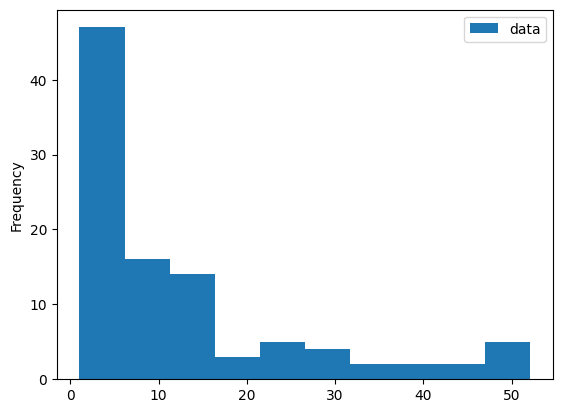

In [4]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

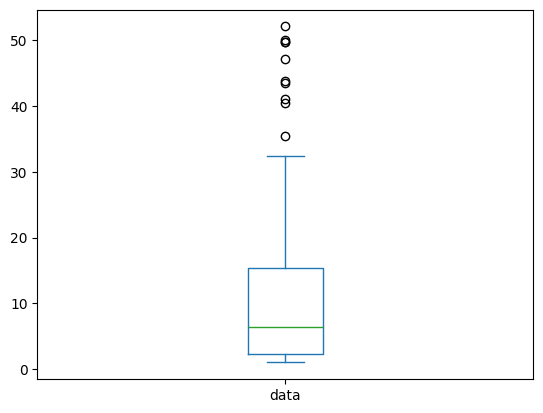

In [5]:
df.plot.box()

A box plot is more effective for quickly identifying the upper range and outliers (the expensive drugs). To enhance it, I would:

Add data points: Overlay a swarm plot or strip plot to show the density of individual data points, especially within the box, giving a better sense of distribution shape.

Label outliers: Annotate extreme outliers with their exact price values.


Clearer labels and title: Use a more descriptive title, like 'Distribution of Drug Prices with Outliers,' and ensure axis labels are clear (e.g., 'Drug Price ($)').

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [6]:
# Download the dataset
!kaggle datasets download -d imakash3011/customer-personality-analysis

# Unzip the downloaded file
!unzip -o customer-personality-analysis.zip

# Load the main CSV file into a pandas DataFrame, specifying tab as a separator
import pandas as pd
df_customer = pd.read_csv('marketing_campaign.csv', sep='\t')

# Display the first 5 rows and information about the DataFrame
display(df_customer.head())
print(df_customer.info())

Dataset URL: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
License(s): CC0-1.0
100% 62.0k/62.0k [00:00<00:00, 41.9MB/s]

Archive:  customer-personality-analysis.zip
  inflating: marketing_campaign.csv  


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Data Cleaning and Initial Exploration

To handle the missing values, specifically in the `Income` column, as it has fewer non-null entries than the total rows, these rows are dropped to ensure othe statistical calculations and visualizations are accurate for complete records. In a more in-depth analysis, imputation strategies may be considered.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows with missing 'Income' values
df_customer_cleaned = df_customer.dropna(subset=['Income']).copy()

print(f"Number of rows after dropping missing income values: {len(df_customer_cleaned)}")
print(df_customer_cleaned.info())

Number of rows after dropping missing income values: 2216
<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null 

### Univariate Analysis: Numerical Features

Analyzing the distribution of the `Income` feature using a histogram, KDE plot, and box plot to understand its shape, central tendency, spread, and identify potential outliers. Calculating mean, median, and mode.

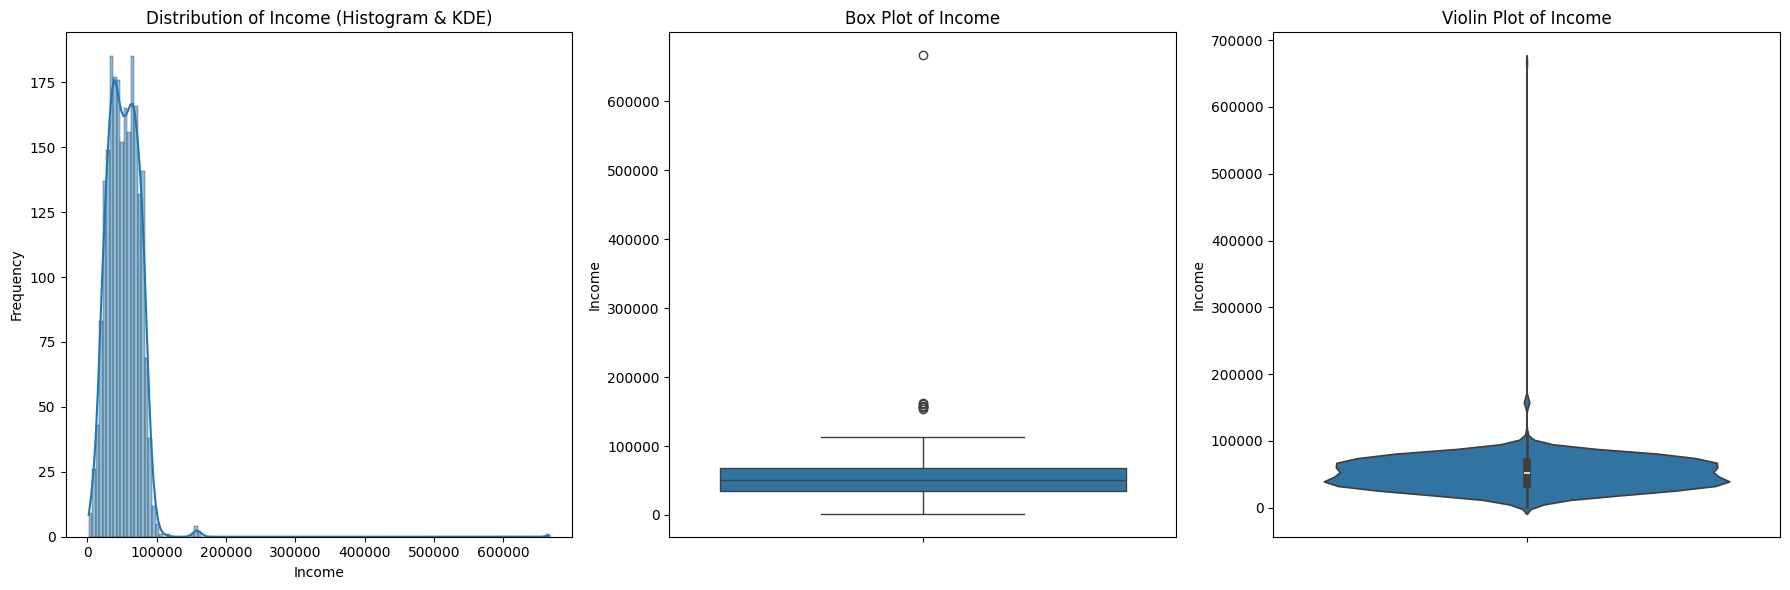


Income - Mean: 52247.25
Income - Median: 51381.50
Income - Mode: 7500.00
Income - Min: 1730.00
Income - Max: 666666.00


In [8]:
plt.figure(figsize=(18, 6))

# Histogram and KDE plot for Income
plt.subplot(1, 3, 1)
sns.histplot(df_customer_cleaned['Income'], kde=True)
plt.title('Distribution of Income (Histogram & KDE)')
plt.xlabel('Income')
plt.ylabel('Frequency')

# Box plot for Income
plt.subplot(1, 3, 2)
sns.boxplot(y=df_customer_cleaned['Income'])
plt.title('Box Plot of Income')
plt.ylabel('Income')

# Violin plot for Income
plt.subplot(1, 3, 3)
sns.violinplot(y=df_customer_cleaned['Income'])
plt.title('Violin Plot of Income')
plt.ylabel('Income')

plt.tight_layout()
plt.show()

# Calculate and print descriptive statistics for Income
income_mean = df_customer_cleaned['Income'].mean()
income_median = df_customer_cleaned['Income'].median()
income_mode = df_customer_cleaned['Income'].mode()[0] # mode() can return multiple values, take the first
income_min = df_customer_cleaned['Income'].min()
income_max = df_customer_cleaned['Income'].max()

print(f"\nIncome - Mean: {income_mean:.2f}")
print(f"Income - Median: {income_median:.2f}")
print(f"Income - Mode: {income_mode:.2f}")
print(f"Income - Min: {income_min:.2f}")
print(f"Income - Max: {income_max:.2f}")

From the `Income` plots:
- **Distribution Shape**: The distribution appears to be right-skewed, meaning there's a long tail towards higher income values, and most customers have lower to moderate incomes.
- **Outliers**: The box plot clearly shows several outliers with very high income values.
- **Min/Max**: The range is quite wide, from `Income - Min: 1730.00` to `Income - Max: 666666.00`.

### Univariate Analysis: Categorical Features

For categorical features like `Education` and `Marital_Status` using bar plots to see the distribution of customers across these categories.

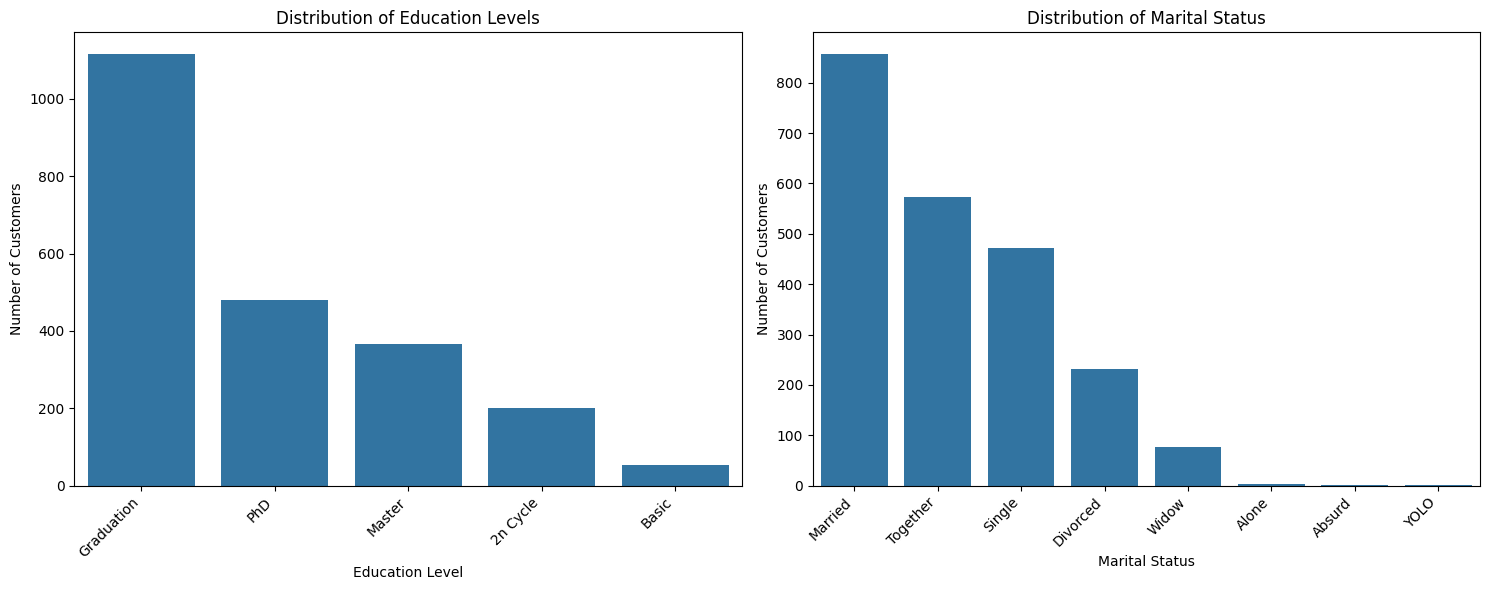

In [9]:
plt.figure(figsize=(15, 6))

# Bar plot for Education
plt.subplot(1, 2, 1)
sns.countplot(data=df_customer_cleaned, x='Education', order=df_customer_cleaned['Education'].value_counts().index)
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')

# Bar plot for Marital_Status
plt.subplot(1, 2, 2)
sns.countplot(data=df_customer_cleaned, x='Marital_Status', order=df_customer_cleaned['Marital_Status'].value_counts().index)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

From the categorical feature plots:
- **Education**: The majority of customers have 'Graduation' level education, followed by 'PhD' and 'Master'. '2n Cycle' and 'Basic' are less common.
- **Marital Status**: 'Married' and 'Together' represent the largest groups, while 'Single' and 'Divorced' are also significant. There are fewer 'Widow' and 'Alone' customers.

### Grouped Histograms

Creating a grouped histogram to see how the `Year_Birth` distribution varies across different `Education` levels. This helps to understand if certain educational backgrounds are more prevalent in specific age groups.

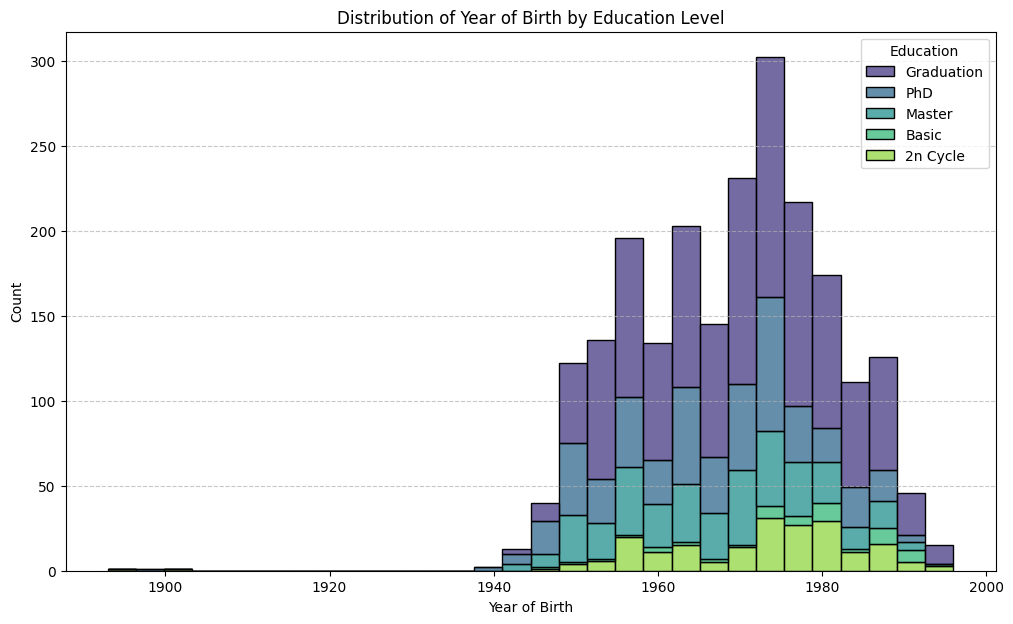

In [10]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df_customer_cleaned, x='Year_Birth', hue='Education', multiple='stack', palette='viridis', bins=30)
plt.title('Distribution of Year of Birth by Education Level')
plt.xlabel('Year of Birth')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the grouped histogram:
- We can observe the age distribution within each education level. For instance, 'Graduation' covers a broad range of birth years, while 'Basic' education appears to be concentrated in earlier birth years (older customers).

### Further Analysis and Conclusions


- **Are the data what you expect?**: The right-skewed income distribution is common in many demographic datasets, where a smaller portion of the population earns significantly more. The distribution of education and marital status also seems reasonable.
- **Are the data likely to be usable?**: Yes, the data appears usable. The presence of outliers in `Income` might require special handling (e.g., capping or transformation) depending on the specific modeling task, but they represent real data points and aren't necessarily errors. The missing `Income` values were handled by dropping, which is a simple approach, but imputation could be considered for more advanced use cases.
- **Overall shape of the distribution for `Income`**: Right-skewed.
- **Outliers present?**: Yes, in the `Income` feature, there are high-income outliers.
- **Minimum and maximum values**: Already calculated for `Income`. For other numerical features, this can be easily extended.
- **Bin sizes affecting histogram**: For `Income`, a default bin size revealed the skewness and outliers. Adjusting bin sizes could highlight different patterns, especially in the lower or higher income ranges, but the current view is sufficient for a general understanding.
- **Does the distribution appear normal?**: No, the `Income` distribution is clearly not normal; it's right-skewed.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

### Univariate Analysis: Spending on Other Products

Analyzing the amount spent on fruits, meat products, fish products, sweet products, and gold products. As these features are crucial for understanding customer preferences and segmenting them based on their purchasing patterns.

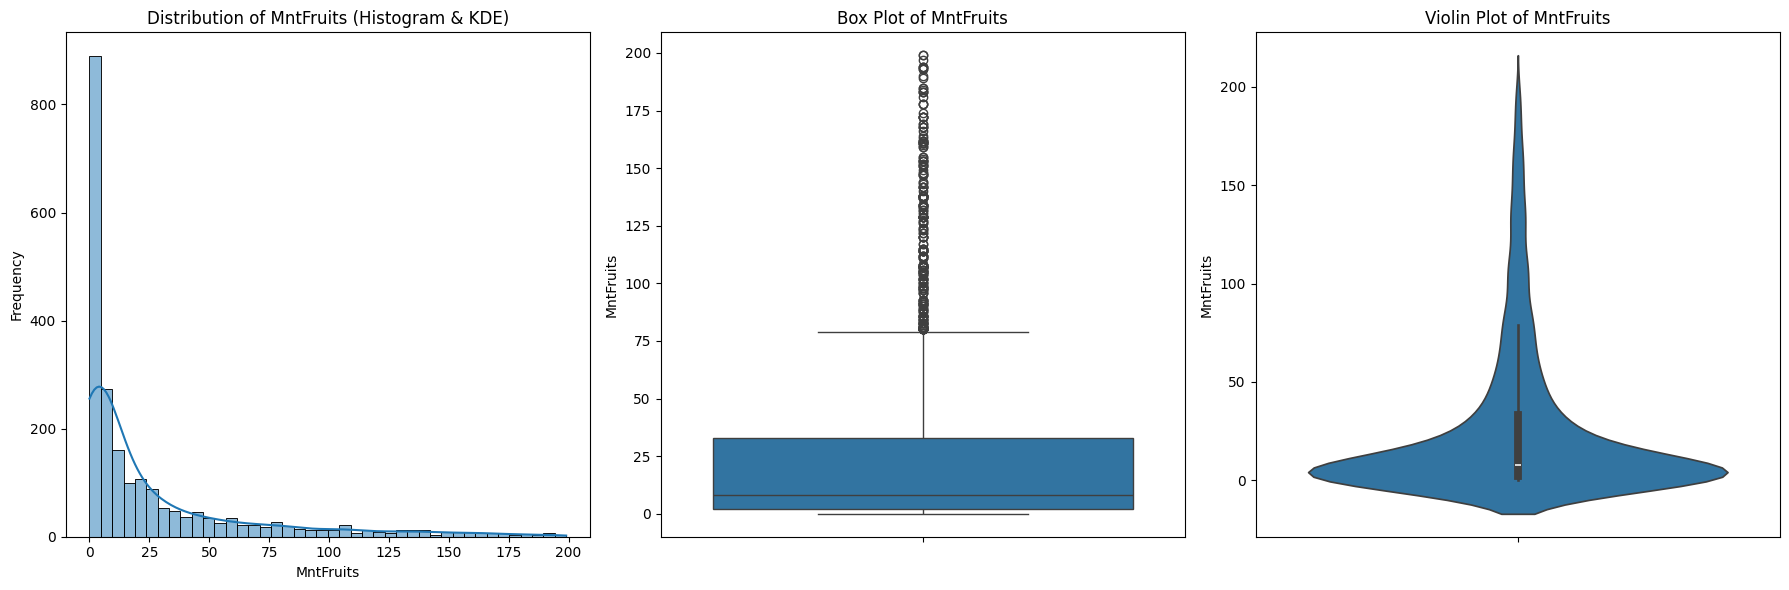


MntFruits - Mean: 26.36
Median: 8.00
Mode: 0
Min: 0.00
Max: 199.00
---------------------------------------------------


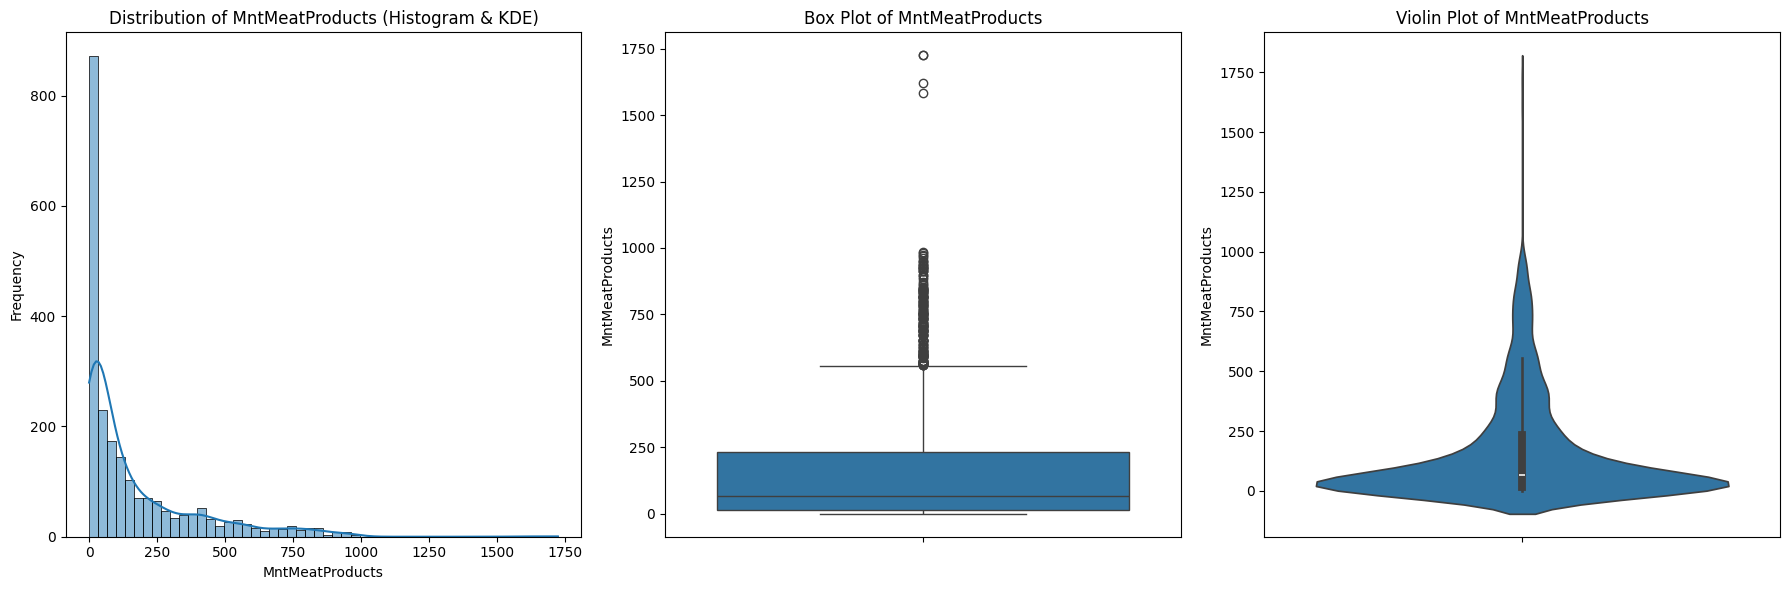


MntMeatProducts - Mean: 167.00
Median: 68.00
Mode: 7
Min: 0.00
Max: 1725.00
---------------------------------------------------


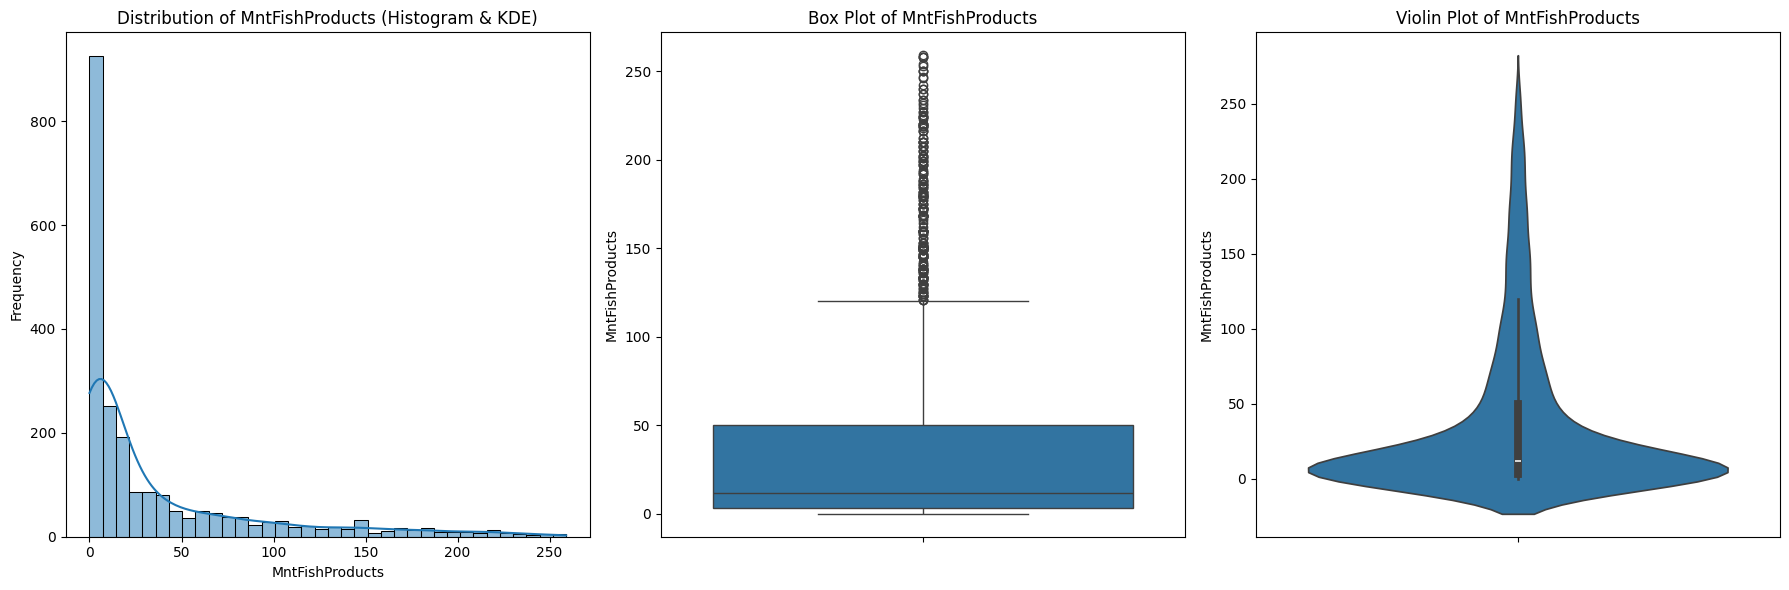


MntFishProducts - Mean: 37.64
Median: 12.00
Mode: 0
Min: 0.00
Max: 259.00
---------------------------------------------------


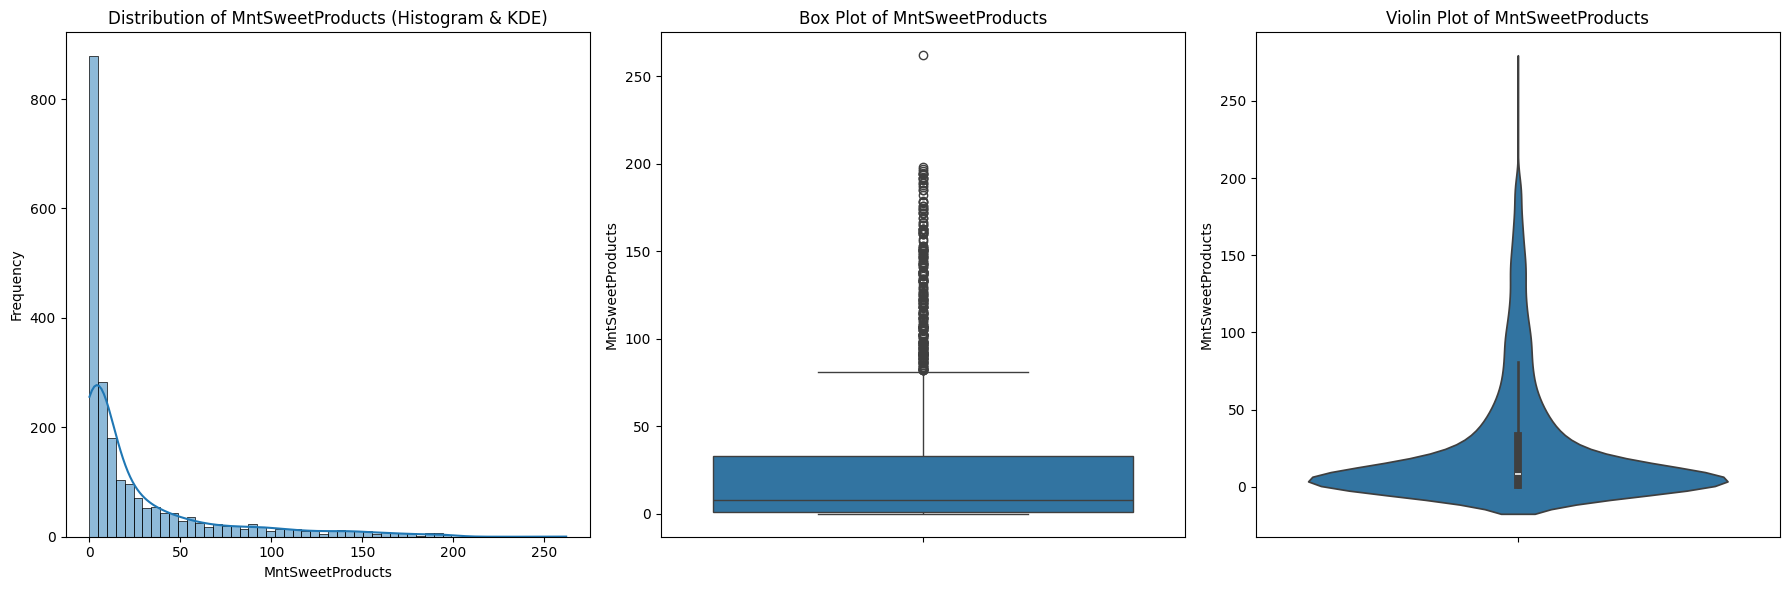


MntSweetProducts - Mean: 27.03
Median: 8.00
Mode: 0
Min: 0.00
Max: 262.00
---------------------------------------------------


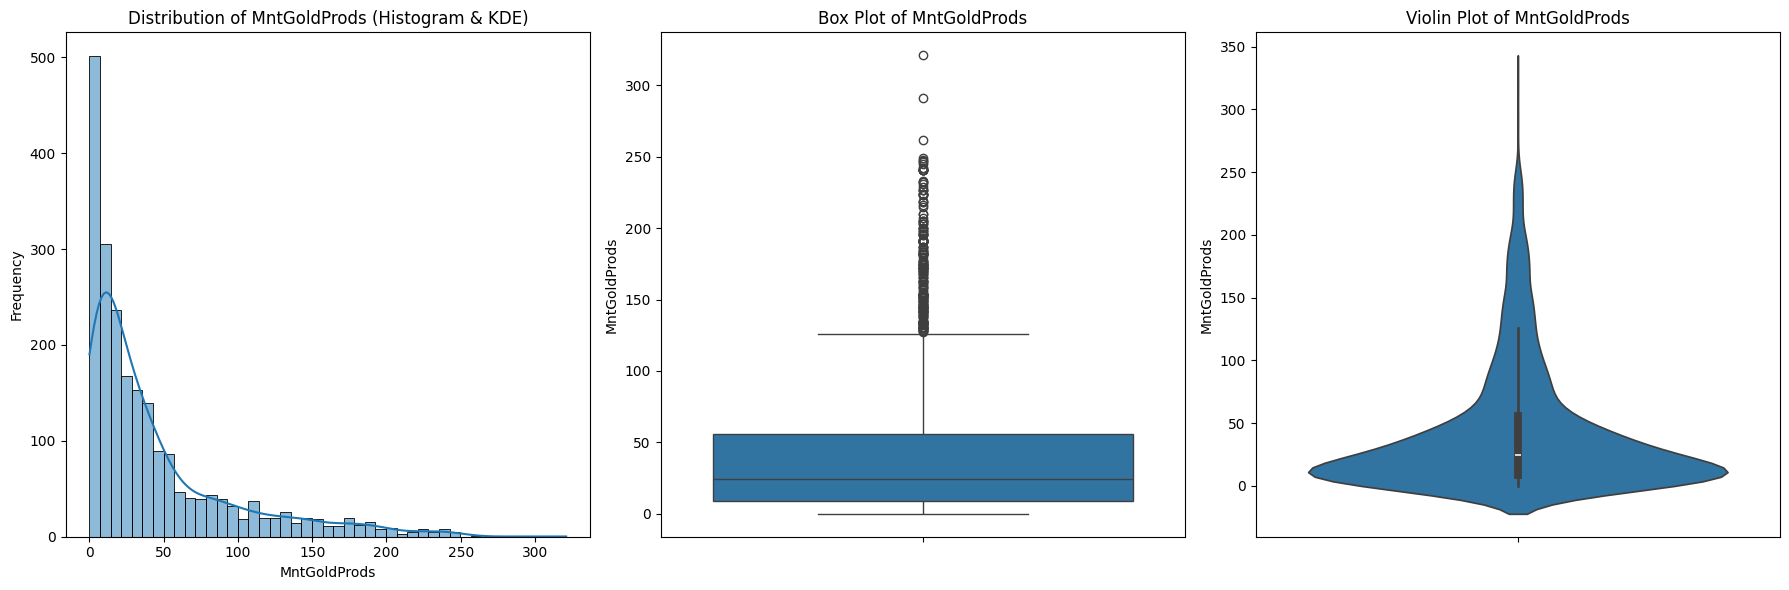


MntGoldProds - Mean: 43.97
Median: 24.50
Mode: 1
Min: 0.00
Max: 321.00
---------------------------------------------------


In [11]:
spending_features = ['MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

for feature in spending_features:
    plt.figure(figsize=(18, 6))

    # Histogram and KDE plot
    plt.subplot(1, 3, 1)
    sns.histplot(df_customer_cleaned[feature], kde=True)
    plt.title(f'Distribution of {feature} (Histogram & KDE)')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Box plot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df_customer_cleaned[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)

    # Violin plot
    plt.subplot(1, 3, 3)
    sns.violinplot(y=df_customer_cleaned[feature])
    plt.title(f'Violin Plot of {feature}')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

    # Calculate and print descriptive statistics
    feat_mean = df_customer_cleaned[feature].mean()
    feat_median = df_customer_cleaned[feature].median()
    feat_mode = df_customer_cleaned[feature].mode()[0] if not df_customer_cleaned[feature].mode().empty else 'N/A'
    feat_min = df_customer_cleaned[feature].min()
    feat_max = df_customer_cleaned[feature].max()

    print(f"\n{feature} - Mean: {feat_mean:.2f}")
    print(f"Median: {feat_median:.2f}")
    print(f"Mode: {feat_mode}")
    print(f"Min: {feat_min:.2f}")
    print(f"Max: {feat_max:.2f}")
    print("---------------------------------------------------")

### Observations from Spending Features:

For `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, and `MntGoldProds`:
- **Distribution Shape**: All these features exhibit a similar pattern to `MntWines`, showing strong right-skewness. A large number of customers spend little to nothing on these categories, with a long tail of higher spenders.
- **Outliers**: Box plots consistently show a significant number of outliers, representing customers who spend considerably more than the average on specific product types.
- **Min/Max**: The minimum for most is 0, indicating many customers don't purchase these items, while the maximum values can be quite high, demonstrating a segment of high-value shoppers.
- **Interpretation**: The prevalence of zero spending and the right-skewed nature suggest that these product categories might appeal to specific customer segments. This insight is valuable for targeted marketing campaigns.


### Univariate Analysis: Number of Purchases and Web Visits

Analyzing the `Num` (number of purchases) features and `NumWebVisitsMonth` to understand customer purchasing frequency across different channels and their online engagement.

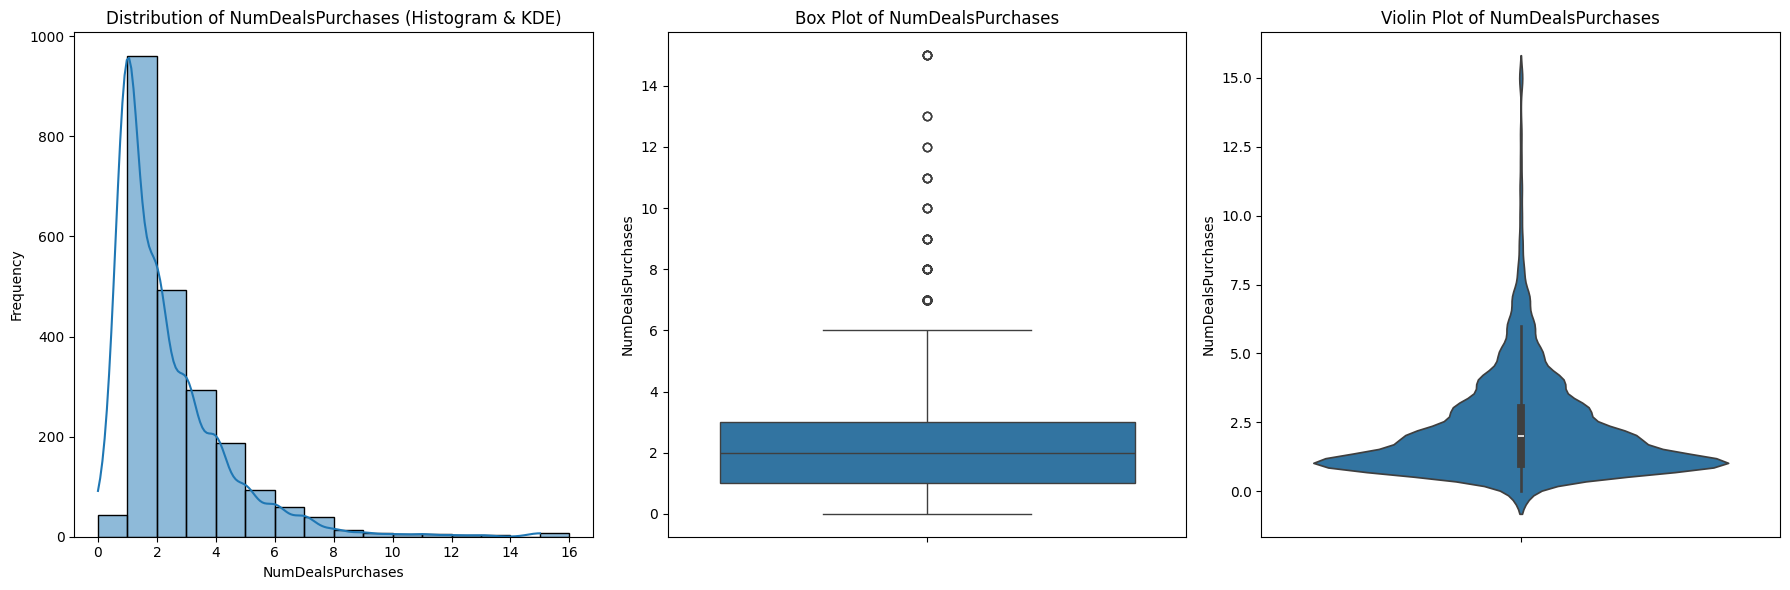


NumDealsPurchases - Mean: 2.32
Median: 2.00
Mode: 1
Min: 0.00
Max: 15.00
---------------------------------------------------


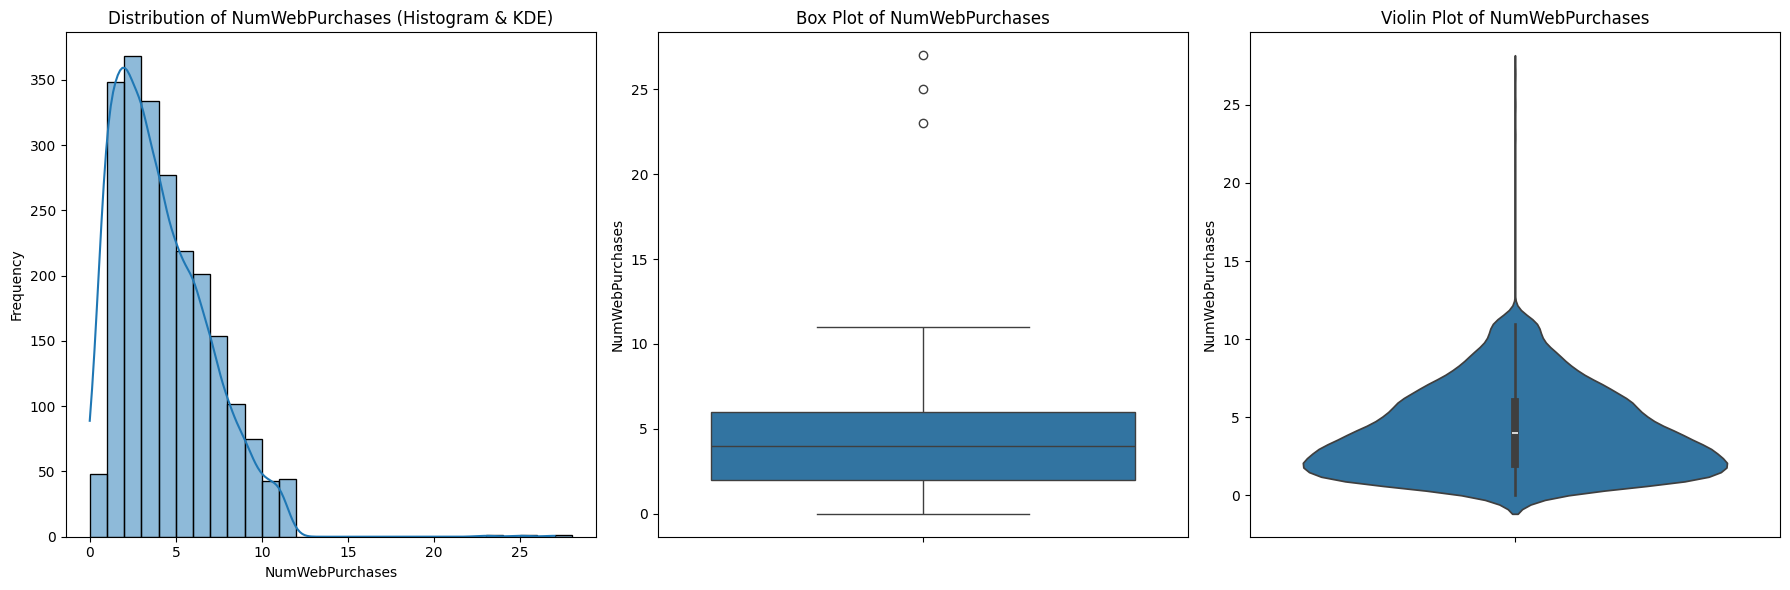


NumWebPurchases - Mean: 4.09
Median: 4.00
Mode: 2
Min: 0.00
Max: 27.00
---------------------------------------------------


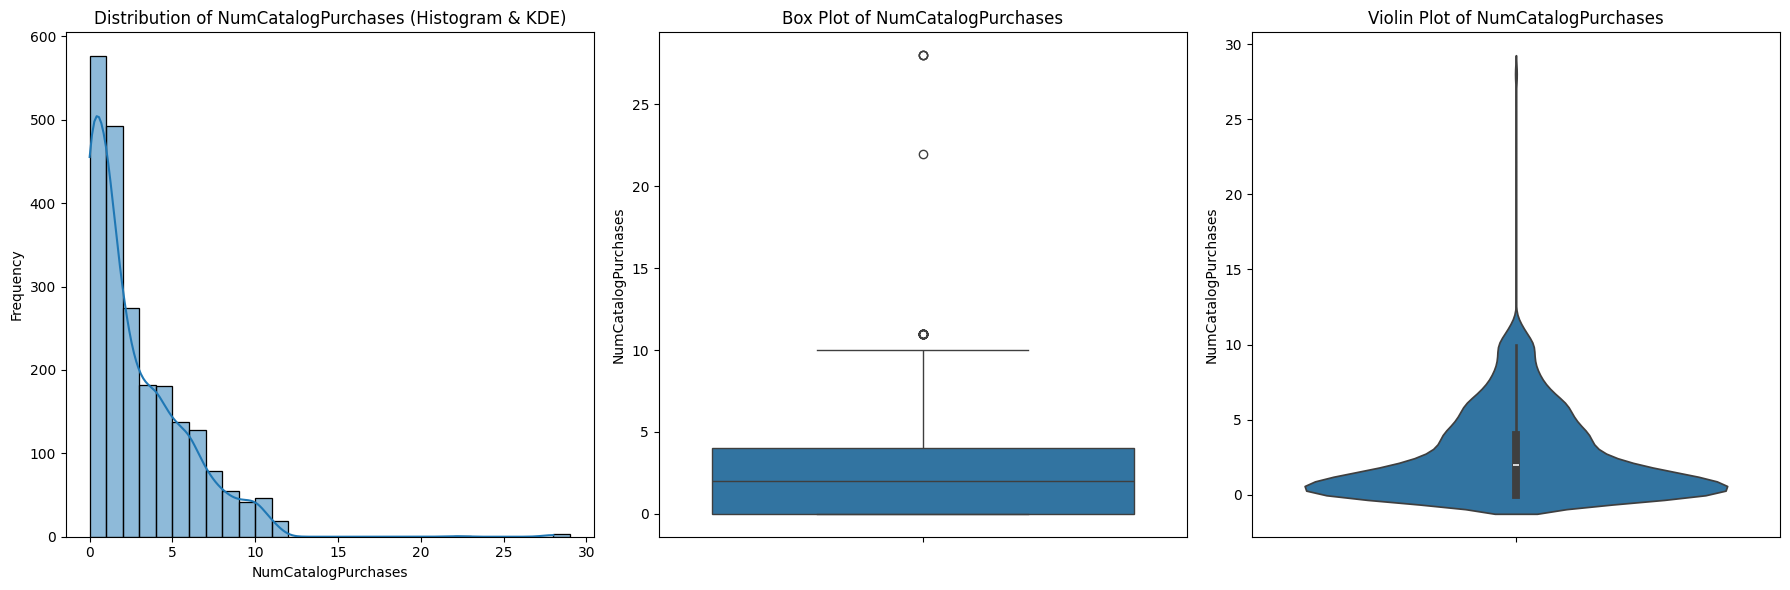


NumCatalogPurchases - Mean: 2.67
Median: 2.00
Mode: 0
Min: 0.00
Max: 28.00
---------------------------------------------------


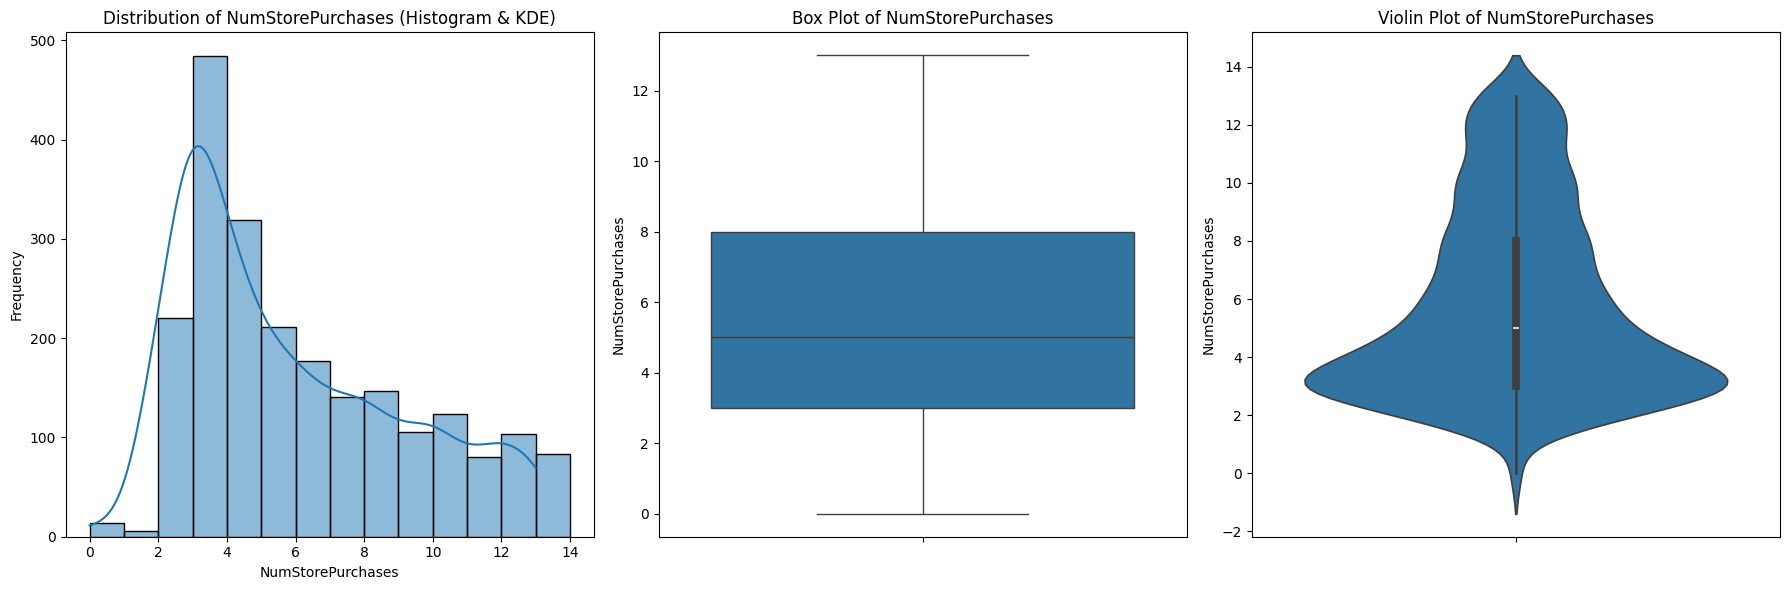


NumStorePurchases - Mean: 5.80
Median: 5.00
Mode: 3
Min: 0.00
Max: 13.00
---------------------------------------------------


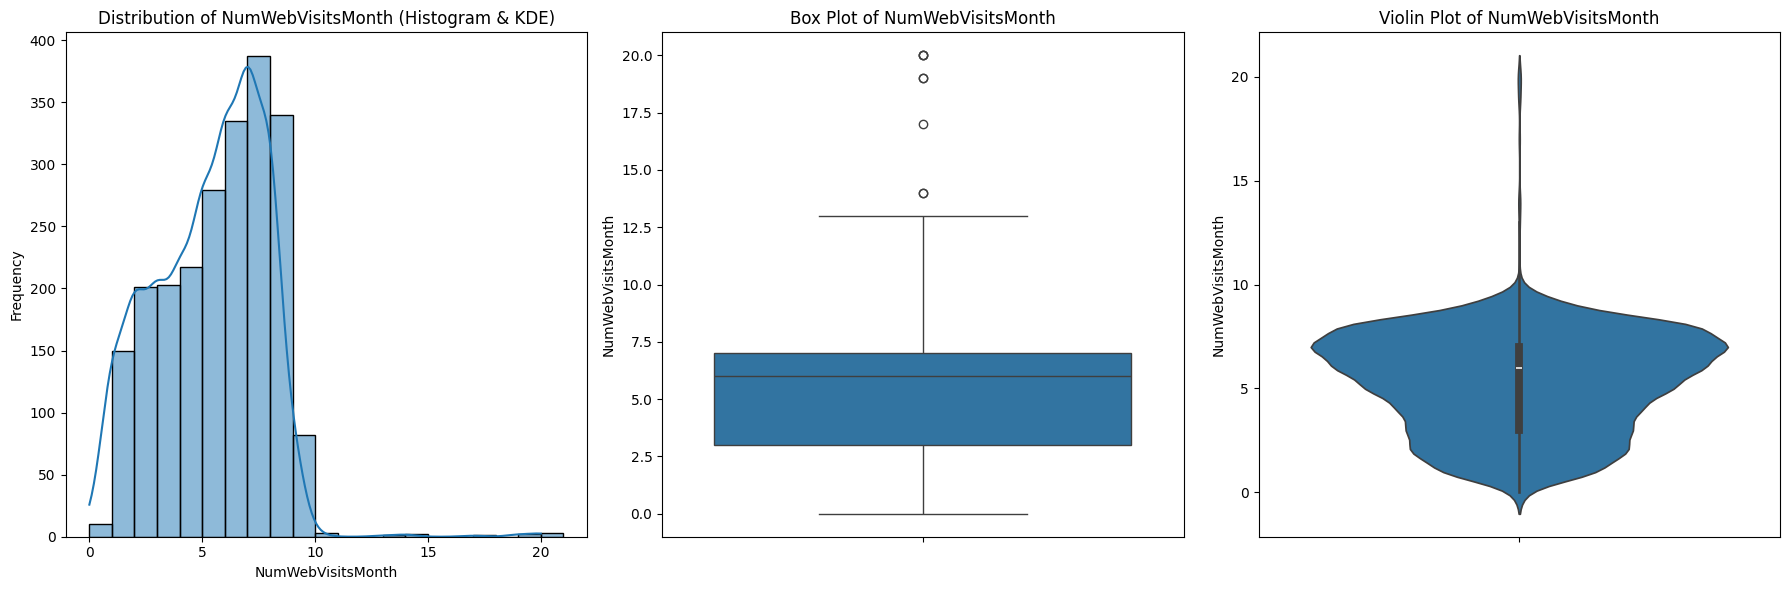


NumWebVisitsMonth - Mean: 5.32
Median: 6.00
Mode: 7
Min: 0.00
Max: 20.00
---------------------------------------------------


In [12]:
purchase_activity_features = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

for feature in purchase_activity_features:
    plt.figure(figsize=(18, 6))

    # Histogram and KDE plot
    plt.subplot(1, 3, 1)
    sns.histplot(df_customer_cleaned[feature], kde=True, bins=range(int(df_customer_cleaned[feature].min()), int(df_customer_cleaned[feature].max()) + 2))
    plt.title(f'Distribution of {feature} (Histogram & KDE)')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Box plot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df_customer_cleaned[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)

    # Violin plot
    plt.subplot(1, 3, 3)
    sns.violinplot(y=df_customer_cleaned[feature])
    plt.title(f'Violin Plot of {feature}')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

    # Calculate and print descriptive statistics
    feat_mean = df_customer_cleaned[feature].mean()
    feat_median = df_customer_cleaned[feature].median()
    feat_mode = df_customer_cleaned[feature].mode()[0] if not df_customer_cleaned[feature].mode().empty else 'N/A'
    feat_min = df_customer_cleaned[feature].min()
    feat_max = df_customer_cleaned[feature].max()

    print(f"\n{feature} - Mean: {feat_mean:.2f}")
    print(f"Median: {feat_median:.2f}")
    print(f"Mode: {feat_mode}")
    print(f"Min: {feat_min:.2f}")
    print(f"Max: {feat_max:.2f}")
    print("---------------------------------------------------")

### Univariate Analysis: More Numerical Features

Analyzing `MntWines` (amount spent on wine), which is a good indicator of customer value.

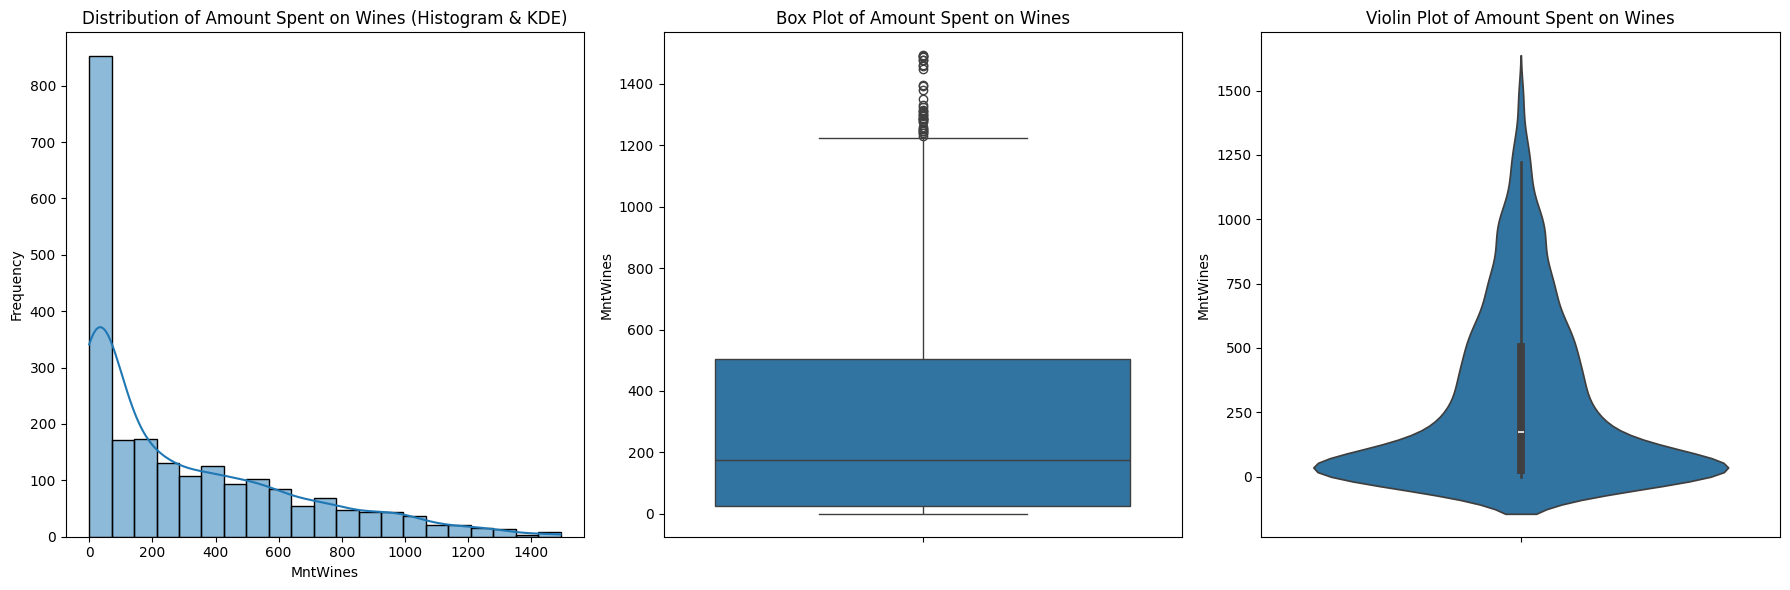


Amount Spent on Wines - Mean: 305.09
Amount Spent on Wines - Median: 174.50
Amount Spent on Wines - Mode: 2
Amount Spent on Wines - Min: 0.00
Amount Spent on Wines - Max: 1493.00


In [13]:
plt.figure(figsize=(18, 6))

# Histogram and KDE plot for MntWines
plt.subplot(1, 3, 1)
sns.histplot(df_customer_cleaned['MntWines'], kde=True)
plt.title('Distribution of Amount Spent on Wines (Histogram & KDE)')
plt.xlabel('MntWines')
plt.ylabel('Frequency')

# Box plot for MntWines
plt.subplot(1, 3, 2)
sns.boxplot(y=df_customer_cleaned['MntWines'])
plt.title('Box Plot of Amount Spent on Wines')
plt.ylabel('MntWines')

# Violin plot for MntWines
plt.subplot(1, 3, 3)
sns.violinplot(y=df_customer_cleaned['MntWines'])
plt.title('Violin Plot of Amount Spent on Wines')
plt.ylabel('MntWines')

plt.tight_layout()
plt.show()

# Calculate and print descriptive statistics for MntWines
mnt_wines_mean = df_customer_cleaned['MntWines'].mean()
mnt_wines_median = df_customer_cleaned['MntWines'].median()
mnt_wines_mode = df_customer_cleaned['MntWines'].mode()[0] if not df_customer_cleaned['MntWines'].mode().empty else 'N/A'
mnt_wines_min = df_customer_cleaned['MntWines'].min()
mnt_wines_max = df_customer_cleaned['MntWines'].max()

print(f"\nAmount Spent on Wines - Mean: {mnt_wines_mean:.2f}")
print(f"Amount Spent on Wines - Median: {mnt_wines_median:.2f}")
print(f"Amount Spent on Wines - Mode: {mnt_wines_mode}")
print(f"Amount Spent on Wines - Min: {mnt_wines_min:.2f}")
print(f"Amount Spent on Wines - Max: {mnt_wines_max:.2f}")

From the `MntWines` plots:
- **Distribution Shape**: The distribution is highly right-skewed, with a large concentration of customers spending very little on wine, and a long tail extending to high spending. This suggests a significant portion of customers are low-spenders on wine, while a few are high-value wine customers.
- **Outliers**: The box plot indicates several outliers on the higher end of spending.
- **Min/Max**: Spending ranges from `0.00` to `1493.00`.



Analyzing `Recency` (number of days since last purchase) for understanding customer engagement.

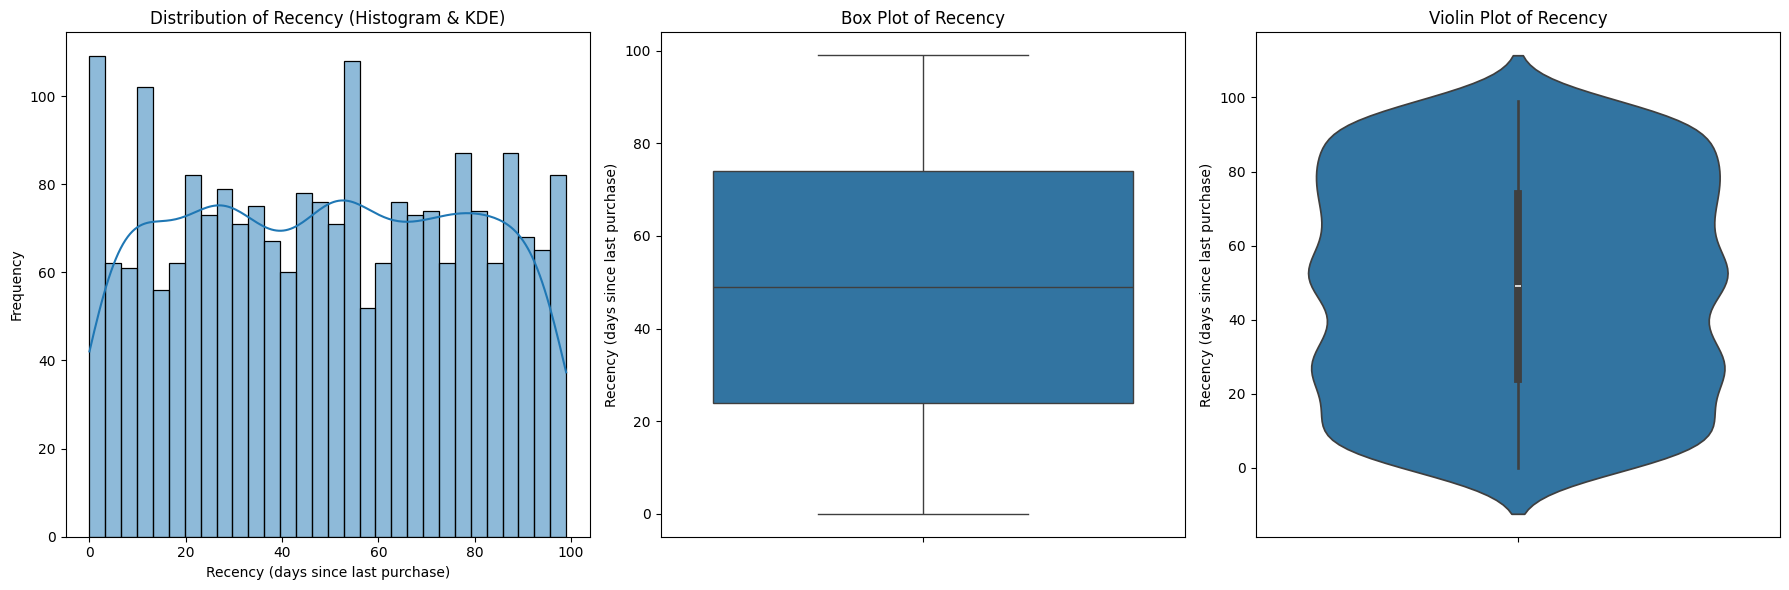


Recency - Mean: 49.01
Recency - Median: 49.00
Recency - Mode: 56
Recency - Min: 0.00
Recency - Max: 99.00


In [14]:
plt.figure(figsize=(18, 6))

# Histogram and KDE plot for Recency
plt.subplot(1, 3, 1)
sns.histplot(df_customer_cleaned['Recency'], kde=True, bins=30)
plt.title('Distribution of Recency (Histogram & KDE)')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Frequency')

# Box plot for Recency
plt.subplot(1, 3, 2)
sns.boxplot(y=df_customer_cleaned['Recency'])
plt.title('Box Plot of Recency')
plt.ylabel('Recency (days since last purchase)')

# Violin plot for Recency
plt.subplot(1, 3, 3)
sns.violinplot(y=df_customer_cleaned['Recency'])
plt.title('Violin Plot of Recency')
plt.ylabel('Recency (days since last purchase)')

plt.tight_layout()
plt.show()

# Calculate and print descriptive statistics for Recency
recency_mean = df_customer_cleaned['Recency'].mean()
recency_median = df_customer_cleaned['Recency'].median()
recency_mode = df_customer_cleaned['Recency'].mode()[0] if not df_customer_cleaned['Recency'].mode().empty else 'N/A'
recency_min = df_customer_cleaned['Recency'].min()
recency_max = df_customer_cleaned['Recency'].max()

print(f"\nRecency - Mean: {recency_mean:.2f}")
print(f"Recency - Median: {recency_median:.2f}")
print(f"Recency - Mode: {recency_mode}")
print(f"Recency - Min: {recency_min:.2f}")
print(f"Recency - Max: {recency_max:.2f}")

From the `Recency` plots:
- **Distribution Shape**: The distribution appears fairly uniform, indicating that customers' last purchases are spread relatively evenly across the entire range of days, from recent to long ago. There isn't a strong peak at either very low or very high recency.
- **Outliers**: No significant outliers are apparent.
- **Min/Max**: Recency ranges from `0.00` to `99.00` days.


# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can. (The second half of chapter two). You do not have to get the exact data values right, just the overall look and feel.

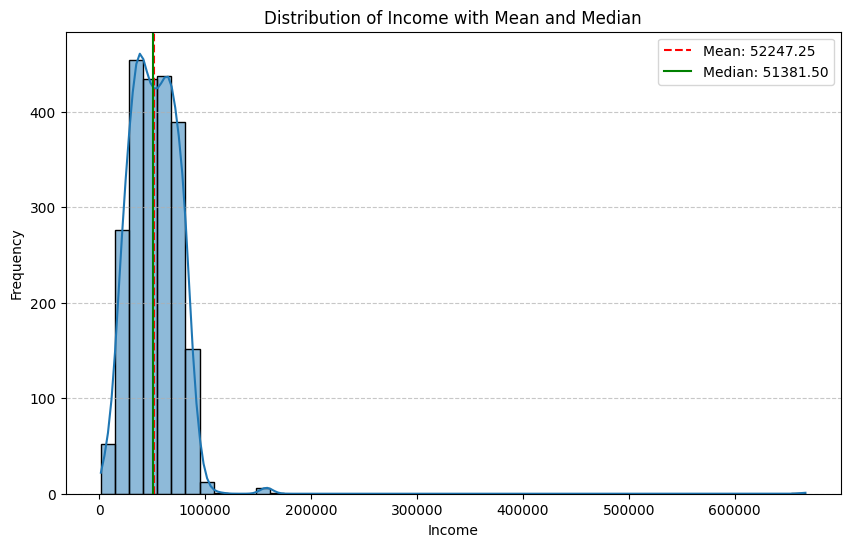

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) # Set a good figure size
sns.histplot(df_customer_cleaned['Income'], kde=True, bins=50)

# Add mean and median lines
income_mean = df_customer_cleaned['Income'].mean()
income_median = df_customer_cleaned['Income'].median()
plt.axvline(income_mean, color='red', linestyle='--', label=f'Mean: {income_mean:.2f}')
plt.axvline(income_median, color='green', linestyle='-', label=f'Median: {income_median:.2f}')

plt.title('Distribution of Income with Mean and Median')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend() # Show the legend for mean and median lines
plt.show()